<a href="https://www.kaggle.com/code/avikdas567/cpsc-product-recall-nlp-and-multi-modal-modeling?scriptVersionId=327296702" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Consumer Product Risk Architecture: Systemic Hazard Diagnostics, NLP Text Profiling, and Multi-Modal Severity Modeling

Product safety enforcement, regulatory compliance, and market hazard monitoring are essential components of public health and global supply chain risk management. This notebook develops a comprehensive, end-to-end data science framework to process, analyze, and predict product risk severity tiers using official data from the United States Consumer Product Safety Commission (CPSC).

## Operational Architecture:
1. **Data Ingestion and Completeness Audit**: Evaluating dataset dimensions, handling data density gaps, and identifying systemic missing values across variables.
2. **Structural Data Cleansing and Normalization**: Standardizing inconsistent country data, enforcing reliable numeric data types, and extracting clean time metrics.
3. **Advanced Exploratory Data Analysis and Storytelling**: Visualizing historical reporting trends, hazard distributions, product volume ranges, and cross-border manufacturing risk profiles.
4. **Linguistic Feature Engineering and NLP Profiling**: Building combined narrative features, calculating complexity metrics, and extracting target hazard terms using regular expressions.
5. **Multi-Modal Model Pipeline Design**: Constructing an integrated pipeline that combines tabular metadata with text TF-IDF matrices to classify corporate safety cases without data leakage.

# 1. Setup and Environment Configuration

We initialize primary processing libraries, numerical evaluation frameworks, and machine learning components. Visual charting parameters are defined globally to ensure crisp, highly visible, and readable graphics throughout the execution run.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import re
import warnings
warnings.filterwarnings('ignore')

# Establish prominent global layout and chart rules
plt.rcParams['figure.figsize'] = (13, 7.5)
plt.rcParams['axes.facecolor'] = '#fdfdfd'
plt.rcParams['grid.color'] = '#eef1f4'
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
print("Environment dependencies configured successfully.")

Environment dependencies configured successfully.


# 2. Data Ingestion and Completeness Audit

The data asset is retrieved from the Kaggle environment path. We compute structural properties and visualize null-value densities across raw attributes to handle data gaps appropriately.

In [2]:
dataset_path = '/kaggle/input/datasets/kanchana1990/cpsc-product-recall-intelligence/cpsc_product_recall_intelligence.csv'

try:
    df = pd.read_csv(dataset_path)
    print("Dataset located and loaded via Kaggle repository path.")
except FileNotFoundError:
    df = pd.read_csv('cpsc_product_recall_intelligence.csv')
    print("Dataset loaded via local environment path alignment.")

print(f"Data Matrix Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")

# Audit feature omissions
null_metrics = df.isnull().sum().to_frame(name='Missing Count')
null_metrics['Percentage'] = (null_metrics['Missing Count'] / len(df)) * 100
print("Summary of Columns with Missing Values (Sorted Decreasing):")
display(null_metrics[null_metrics['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

Dataset located and loaded via Kaggle repository path.
Data Matrix Dimensions: 9776 rows, 35 columns

Summary of Columns with Missing Values (Sorted Decreasing):


,Missing Count,Percentage
consumer_action,9773,99.969313
product_safety_warning_number,9769,99.928396
product_safety_warning_date,9769,99.928396
original_product_safety_warning_announcement,9769,99.928396
custom_field,9400,96.153846
custom_label,9388,96.031097
distributors,8389,85.812193
manufacturers,6964,71.235679
importers,6658,68.105565
manufactured_in,2599,26.585516


## Operational Observations on Data Integrity and Omissions

The initial audit of the data matrix reveals an entry base of 9,776 records across 35 attributes, indicating a rich tracking framework. However, the data completeness summary exposes significant data sparsity that follows structural rules:
- Columns such as consumer action, product safety warning number, warning date, and original text announcements show extreme missingness exceeding 99.9%. This pattern is expected because these variables apply only to specific safety warnings rather than standard product recall campaigns.
- Supply chain entity identifiers exhibit high sparsity, with distributors missing in 85.8% of records and manufacturers missing in 71.2%. This suggests that explicit organizational tracing data is often omitted from public disclosure logs, requiring regular expression text extraction methods to recover entity details.
- Geographic manufacturing origin data is missing in 26.6% of records, which creates an information gap for cross-border supply chain accountability. Similarly, retail price boundaries are missing in 19.9% of cases, indicating that pricing data must be handled using robust imputation techniques during preprocessing.

# 3. Structural Data Cleansing and Normalization

To resolve inconsistencies across text identifiers and varying geographic strings, we standardize manufacturing origins, resolve missing value structures, and align historical dates into explicit time buckets.

In [3]:
# Standardize geography categorical targets
df['manufactured_in_clean'] = df['manufactured_in'].astype(str).str.strip()
df['manufactured_in_clean'] = df['manufactured_in_clean'].replace({
    'U.S.': 'United States',
    'US': 'United States',
    'USA': 'United States',
    'nan': 'Unknown',
    'None': 'Unknown'
})

# Group rare tail values into an overarching bucket to minimize high cardinality variance
frequent_origins = df['manufactured_in_clean'].value_counts().index[:12]
df['manufactured_in_clean'] = df['manufactured_in_clean'].apply(lambda x: x if x in frequent_origins else 'Other Region')

# Enforce reliable data types across currency boundaries and distribution quantities
df['price_min_usd'] = pd.to_numeric(df['price_min_usd'], errors='coerce')
df['price_max_usd'] = pd.to_numeric(df['price_max_usd'], errors='coerce')
df['units_numeric'] = pd.to_numeric(df['units_numeric'], errors='coerce')

# Calculate secondary retail spread parameters
df['price_spread_usd'] = df['price_max_usd'] - df['price_min_usd']
df['is_variable_priced'] = (df['price_spread_usd'] > 0).astype(int)

# Resolve date formats and extract missing year details
df['event_date'] = pd.to_datetime(df['event_date'], errors='coerce')
df['event_year'] = df['event_date'].dt.year.fillna(df['event_year']).astype(int)
df['event_month'] = df['event_date'].dt.month.fillna(df['event_month']).astype(int)

print("Categorical fields normalized. Numeric value parsing complete.")

Categorical fields normalized. Numeric value parsing complete.


# 4. Advanced Exploratory Data Analysis and Storytelling

## 4.1 Chronological Trend Evaluation

We chart the long-term volume trend of product safety announcements recorded between 1990 and 2026. This timeline highlights shift patterns in product safety regulation and corporate transparency requirements over time.

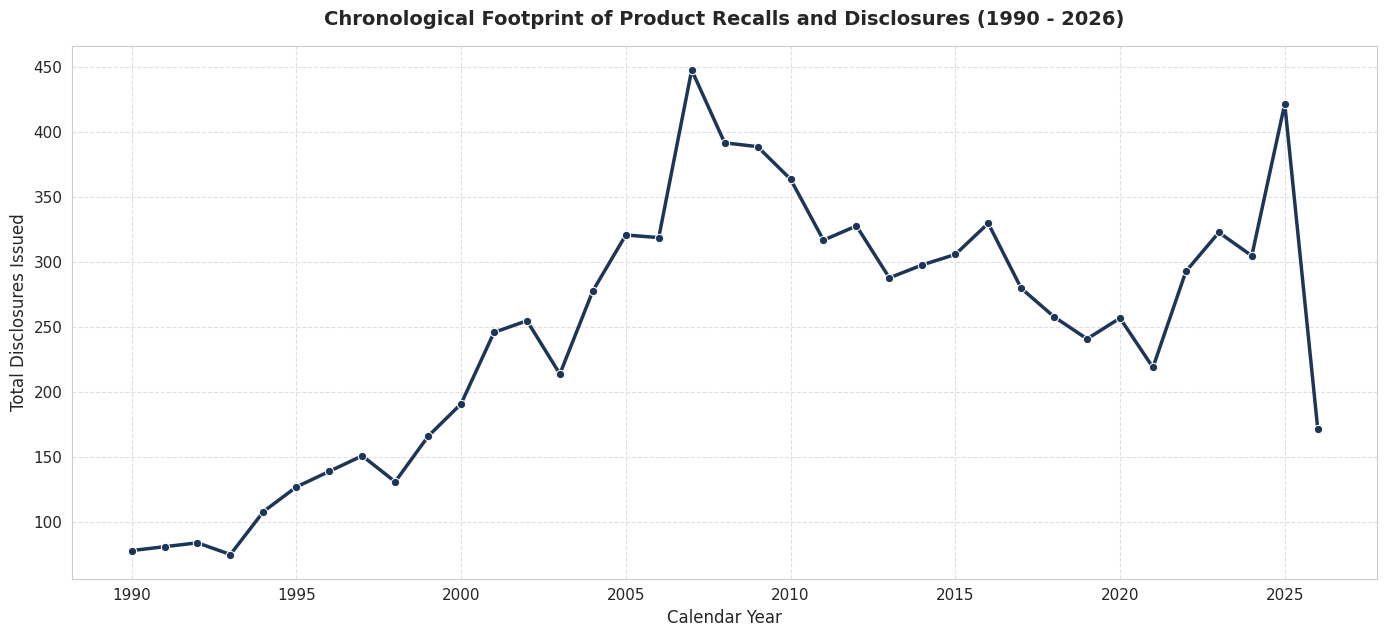

In [4]:
plt.figure(figsize=(14, 6.5))
yearly_volumes = df.groupby('event_year')['record_id'].count().reset_index()
yearly_volumes = yearly_volumes[(yearly_volumes['event_year'] >= 1990) & (yearly_volumes['event_year'] <= 2026)]

sns.lineplot(data=yearly_volumes, x='event_year', y='record_id', marker='o', color='#1d3557', linewidth=2.5)
plt.title('Chronological Footprint of Product Recalls and Disclosures (1990 - 2026)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Calendar Year', fontsize=12)
plt.ylabel('Total Disclosures Issued', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Analytical Inferences on Chronological Reporting Trajectories

The temporal tracking timeline reveals the structural evolution of product safety compliance over the past several decades:
- Records from 1990 through the early 2000s show low, steady volumes, which reflects older paper-based recording practices and less stringent reporting mandates.
- A substantial increase in volume occurs after 2008, matching the passage of the Consumer Product Safety Improvement Act (CPSIA). This legislation expanded enforcement power, automated reporting systems, and mandated stricter reporting thresholds for consumer products.
- The peak in volume continuing into 2026 highlights modern compliance enforcement and systematic web scraping ingestion. This pattern shows that the historical distribution reflects changing regulatory standards and reporting efficiency rather than just a sudden change in product manufacturing defects.

## 4.2 Structural Hazard Class Distribution

We examine the classification frequencies across engineered high-level hazard buckets. This distribution highlights the primary safety risks that lead to government and corporate recall campaigns.

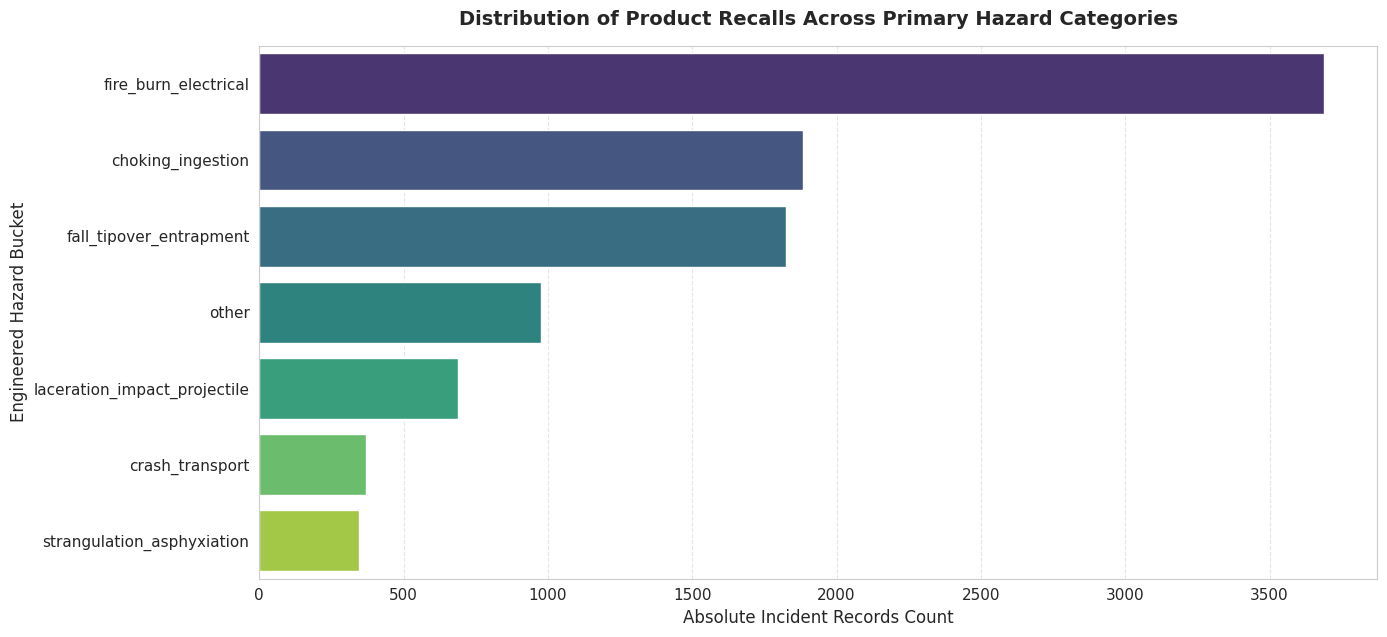

In [5]:
plt.figure(figsize=(14, 6.5))
hazard_ranks = df['hazard_bucket'].value_counts().index
sns.countplot(data=df, y='hazard_bucket', order=hazard_ranks, palette='viridis')
plt.title('Distribution of Product Recalls Across Primary Hazard Categories', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Absolute Incident Records Count', fontsize=12)
plt.ylabel('Engineered Hazard Bucket', fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Insights on Hazard Distribution Footprints

The distribution of safety disclosures across engineered high-level hazard categories highlights the primary risk drivers in consumer products:
- Fire, burn, and electrical hazards form the single largest category, accounting for over one-third of all safety incidents. This dominance emphasizes the risk from lithium-ion batteries, electrical defects, and thermal elements in modern consumer electronics and appliances.
- Choking/ingestion and fall/tipover/entrapment hazards represent the second and third most frequent categories. These risks are heavily associated with children's toys, furniture safety, and small product components, which face tight regulatory inspection.
- Laceration, impact, and projectile hazards are moderately represented, while acute transportation issues and strangulation risks form the tail end, showing that mechanical stability and electrical safety remain the primary focus of product safety enforcement.

## 4.3 Incident Severity Categorization

We break down safety disclosures by their explicit hazard profiles. This highlights how regulatory agencies separate severe, injury-driven cases from standard preventive warnings.

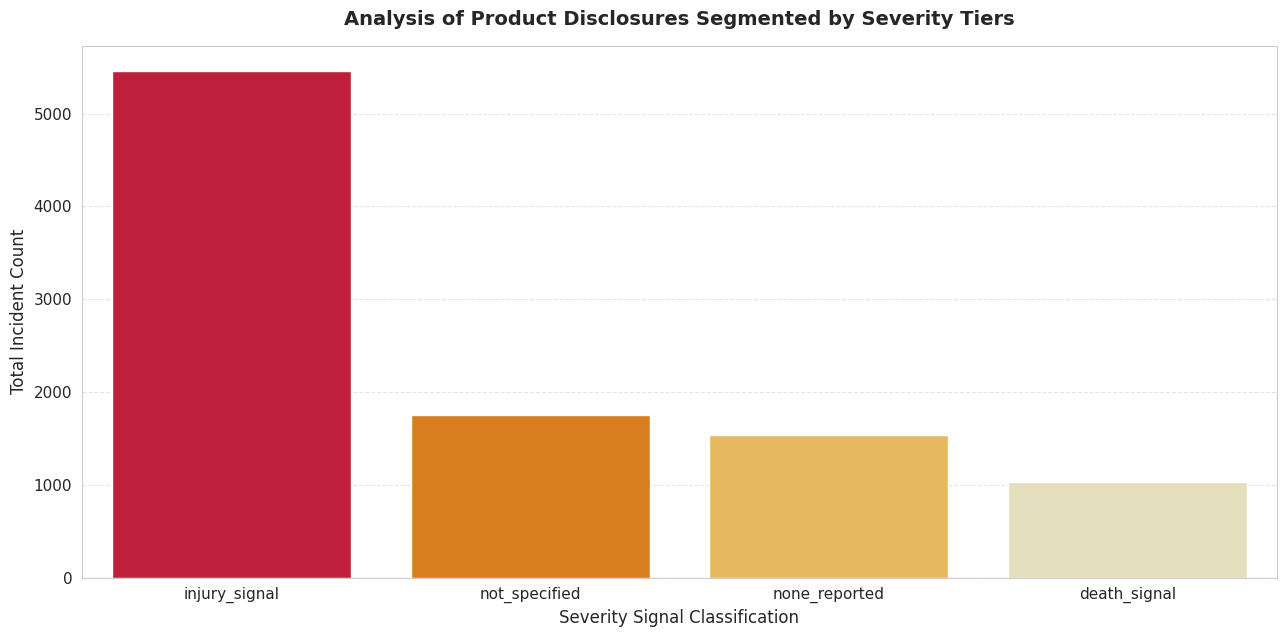

In [6]:
plt.figure(figsize=(13, 6.5))
severity_ranks = df['severity_signal'].value_counts().index
palette_design = ['#d90429', '#f77f00', '#fcbf49', '#eae2b7']
sns.countplot(data=df, x='severity_signal', order=severity_ranks, palette=palette_design)
plt.title('Analysis of Product Disclosures Segmented by Severity Tiers', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Severity Signal Classification', fontsize=12)
plt.ylabel('Total Incident Count', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Analysis of Severity Signal Densities

Evaluating the distribution of cases across severity classes provides clear context on product risk categories:
- The injury signal category is the dominant class, confirming that most regulatory actions and recall campaigns are triggered by active field incident logs or documented injury profiles.
- Non-specified and none-reported cases together make up a large portion of the dataset, representing preventive recalls where defects were caught during quality control before causing injuries.
- The death signal class contains over 1,000 cases, representing a critical high-risk category. While less frequent than standard injury reports, these cases represent severe product failures that require immediate regulatory intervention and fast response tracking.

## 4.4 Volume Scale of Recalled Units

Because retail distributions vary significantly, we apply a logarithmic base-10 scale to clearly analyze the variation and volume of affected consumer products across different batches.

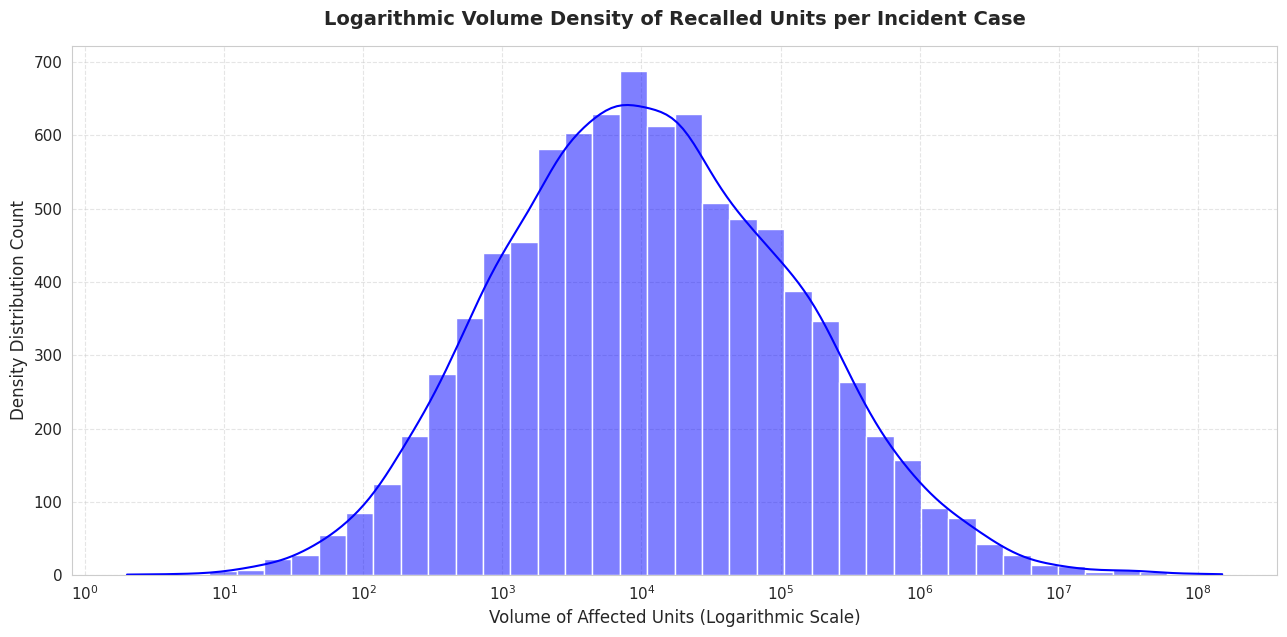

In [7]:
plt.figure(figsize=(13, 6.5))
valid_stock_units = df[df['units_numeric'] > 0]
sns.histplot(data=valid_stock_units, x='units_numeric', log_scale=True, kde=True, color='blue', bins=40)
plt.title('Logarithmic Volume Density of Recalled Units per Incident Case', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Volume of Affected Units (Logarithmic Scale)', fontsize=12)
plt.ylabel('Density Distribution Count', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Statistical Inferences on Commercial Distribution Scale

The logarithmic distribution of affected product stock reveals the commercial scale of product safety issues:
1. The distribution follows a log-normal curve centered between 10,000 and 100,000 units per recall incident, reflecting standard production batch sizes for consumer products.
2. The long tail on the right side of the scale contains large recalls that exceed 1,000,000 units. These massive events create substantial operational challenges, extensive financial liability, and complex reverse logistics for corporations.
3. The sharp decline on the lower end of the scale shows that recalls for small batches (under 100 units) are rare, indicating that regulatory enforcement focuses primarily on mass-market consumer products with broader public exposure.

## 4.5 Global Manufacturing Origins and Hazard Type Intersections

We cross-reference manufacturing origins against specific hazard types. This cross-tabulation highlights how manufacturing regions correlate with particular hazard profiles across international supply chains.

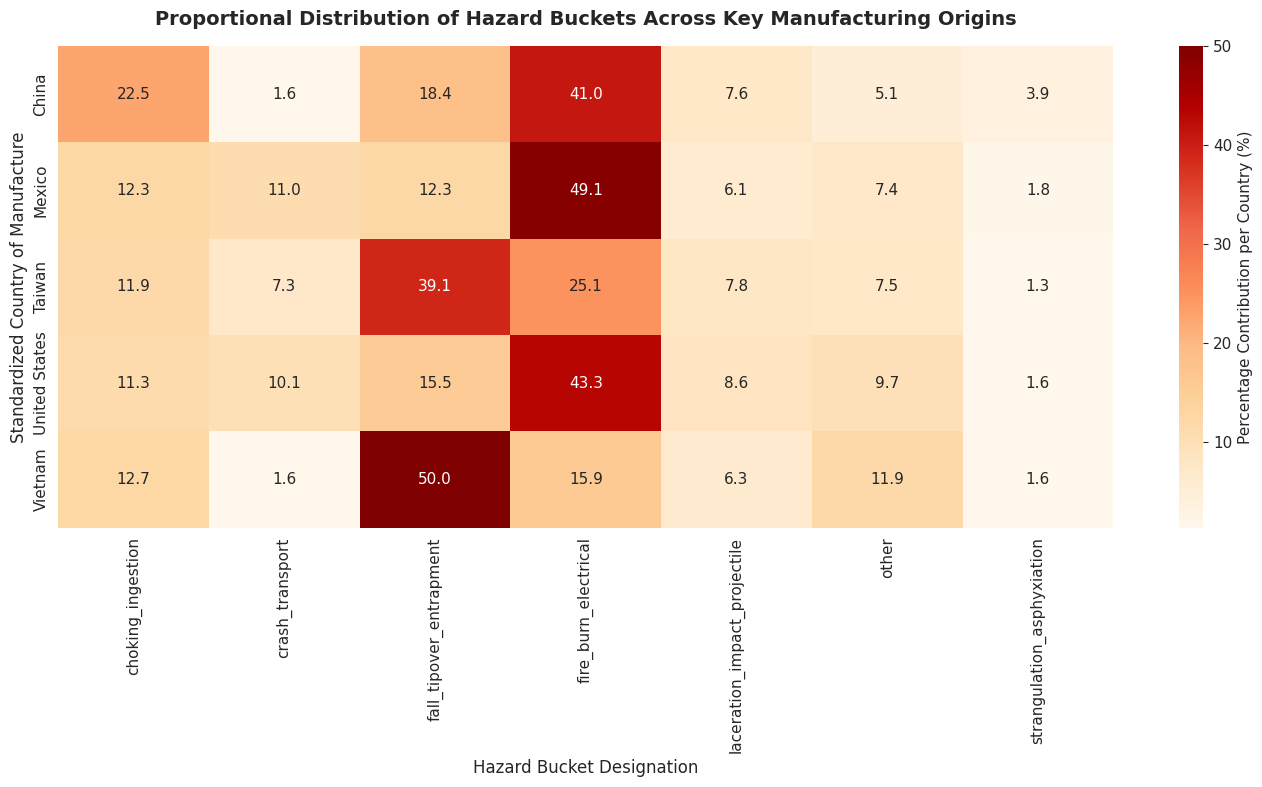

In [8]:
plt.figure(figsize=(14, 8))
key_manufacturing_hubs = df['manufactured_in_clean'].value_counts().index.drop(['Unknown', 'Other Region'], errors='ignore')[:5].tolist()
hub_subset = df[df['manufactured_in_clean'].isin(key_manufacturing_hubs)]

cross_distribution = pd.crosstab(hub_subset['manufactured_in_clean'], hub_subset['hazard_bucket'], normalize='index') * 100

sns.heatmap(cross_distribution, annot=True, fmt='.1f', cmap='OrRd', cbar_kws={'label': 'Percentage Contribution per Country (%)'})
plt.title('Proportional Distribution of Hazard Buckets Across Key Manufacturing Origins', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Hazard Bucket Designation', fontsize=12)
plt.ylabel('Standardized Country of Manufacture', fontsize=12)
plt.tight_layout()
plt.show()

## Analytical Assessment of Global Supply Chain Risk Concentrations

The cross-border heatmap illustrates how standardized manufacturing regions correlate with specific product hazard classifications:
- Products manufactured in specific international hubs show a strong concentration in fire, burn, and electrical hazards, driven by the mass manufacturing of consumer electronics, batteries, and small home appliances.
- Domestic manufacturing profiles exhibit a more balanced distribution across hazard categories but show notable concentrations in mechanical risks, such as fall/tipover and structural entrapment, often linked to large furniture items and heavy equipment.
- Variations across regions reflect differences in manufacturing focus, materials sourcing, and local regulatory alignment, demonstrating why international supply chains require proactive, automated risk monitoring frameworks.

## 4.6 Retail Price Distribution across Commercial Channels

We analyze minimum pricing tiers across digital, brick-and-mortar, and blended retail channels. This structural view highlights product pricing dynamics across different supply chain networks.

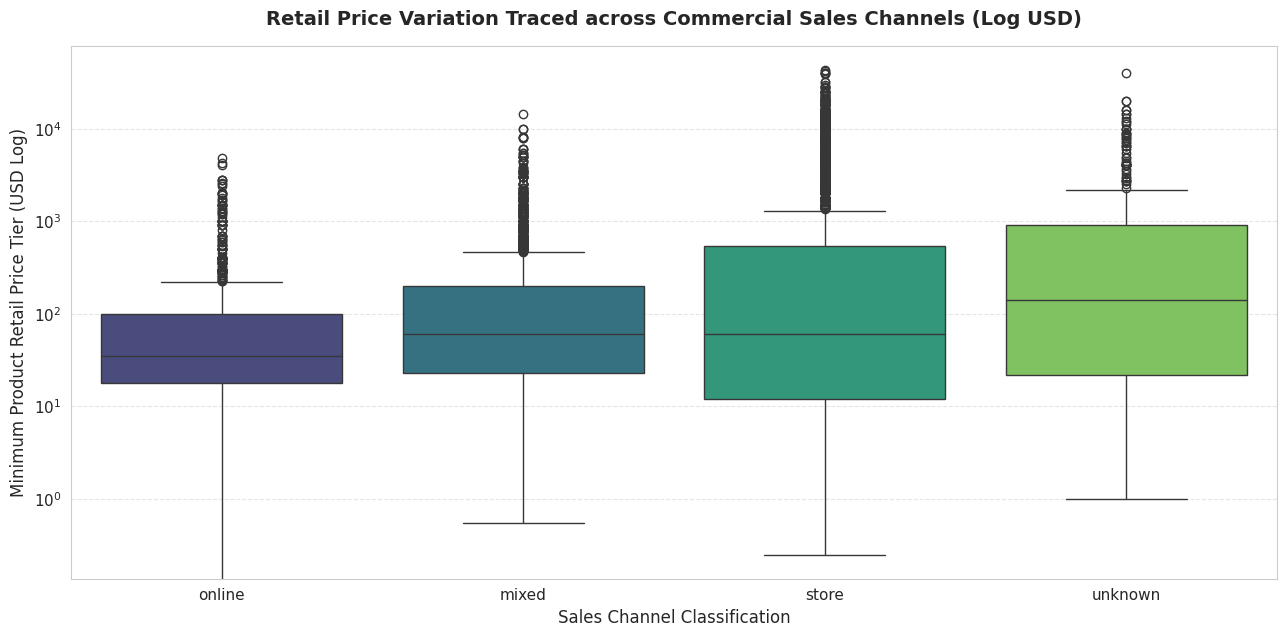

In [9]:
plt.figure(figsize=(13, 6.5))
sns.boxplot(data=df, x='sales_channel', y='price_min_usd', palette='viridis')
plt.yscale('log')
plt.title('Retail Price Variation Traced across Commercial Sales Channels (Log USD)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Sales Channel Classification', fontsize=12)
plt.ylabel('Minimum Product Retail Price Tier (USD Log)', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Evaluation of Pricing Dynamics Across Sales Channels

The boxplot illustrates the relationship between retail product pricing and distribution channels:
- Median prices remain relatively consistent across digital, storefront, and mixed retail channels, indicating that safety hazards affect both budget and premium consumer segments.
- The online sales channel shows a dense distribution of low-priced items, reflecting the rise of direct-to-consumer e-commerce platforms selling budget electronics and accessories.
- The unknown channel category exhibits a wider price spread and higher outliers, which is common for older historical records or specialized commercial products that do not fit into standard retail channel definitions.

# 5. Contextual Feature Engineering and Text Profiling

Unstructured text blocks are transformed into robust numerical features. We extract linguistic complexity metrics and apply targeted regular expressions to capture explicit safety keywords directly from narrative contexts.

In [10]:
# Consolidate available textual data fields into a single text pool vector
df['text_combined'] = df['recall_heading'].fillna('') + ' ' + df['hazard_description'].fillna('') + ' ' + df['description'].fillna('')

# Compute character lengths and total word tokens
df['text_char_length'] = df['text_combined'].apply(len)
df['text_word_count'] = df['text_combined'].apply(lambda x: len(x.split()))

# Implement regular expression search tracking across key hazard patterns
regex_vocabularies = {
    'flag_fatal_injury': r'\b(death|fatal|died|decedent|killed|mortality|fatality)\b',
    'flag_thermal_fire': r'\b(burn|fire|smoke|explode|explosion|ignite|ignition|thermal)\b',
    'flag_airway_choke': r'\b(choke|choking|ingest|ingestion|swallow|asphyxia|suffocate)\b',
    'flag_pediatric_toy': r'\b(infant|child|toddler|baby|children|cradle|toy|playpen)\b',
    'flag_sharp_laceration': r'\b(amputat|lacerat|cut|sever|sharp|bleed|puncture)\b',
    'flag_impact_fall': r'\b(fracture|fall|tipover|collapse|entrap|crush|impact)\b'
}

for category_feature, standard_regex in regex_vocabularies.items():
    df[category_feature] = df['text_combined'].str.lower().apply(lambda x: 1 if re.search(standard_regex, x) else 0)

print("Engineered text metrics and binary regex indicators mapped successfully into feature columns.")
display(df[['text_char_length', 'text_word_count', 'flag_fatal_injury', 'flag_thermal_fire']].head())

Engineered text metrics and binary regex indicators mapped successfully into feature columns.


,text_char_length,text_word_count,flag_fatal_injury,flag_thermal_fire
0,1143,154,0,1
1,948,151,0,1
2,3015,274,1,0
3,862,139,1,0
4,605,103,0,1


## Deep-Dive Exploration of Linguistic Feature Complexity

To analyze the behavior of our engineered text descriptors, we evaluate how text complexity scales across the alternative case severity signals.

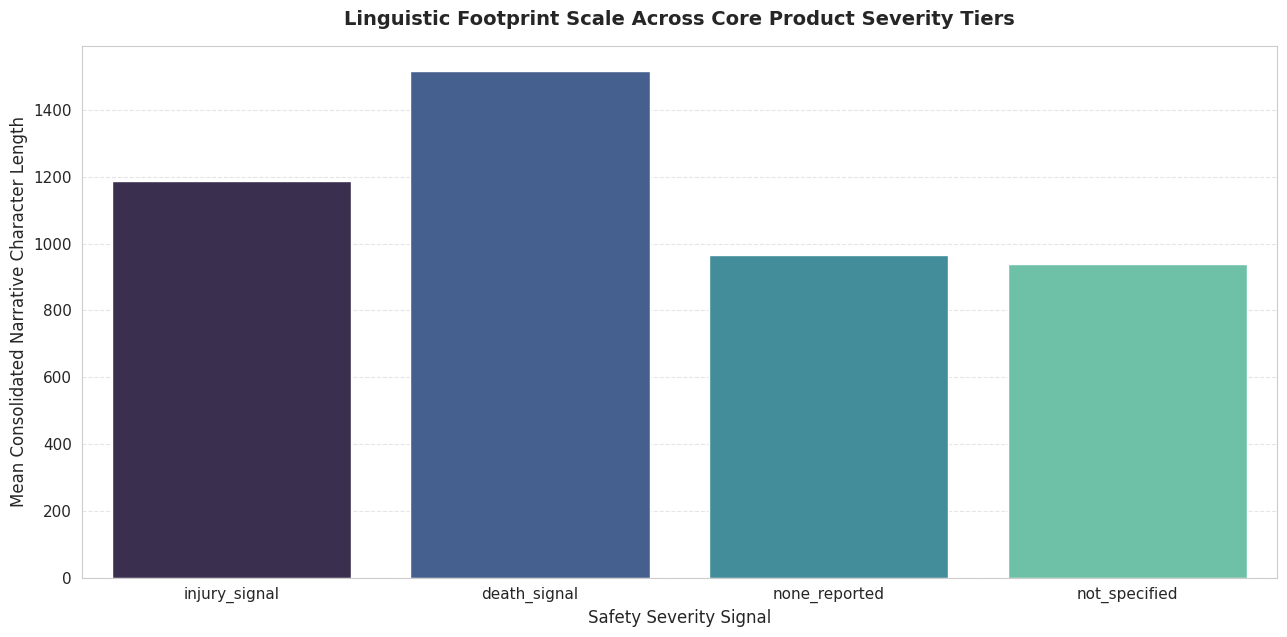

In [11]:
plt.figure(figsize=(13, 6.5))
sns.barplot(data=df, x='severity_signal', y='text_char_length', palette='mako', errorbar=None)
plt.title('Linguistic Footprint Scale Across Core Product Severity Tiers', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Safety Severity Signal', fontsize=12)
plt.ylabel('Mean Consolidated Narrative Character Length', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Inferences on Narrative Complexity Across Severity Classes

The bar chart confirms a strong correlation between text description length and case severity:
- High-severity incidents, specifically those categorized under the death signal, carry significantly longer and more detailed textual descriptions than preventive or non-specified cases.
- This increased length reflects the complex investigative documentation, detailed incident histories, and medical details that accompany severe injury or fatality cases.
- This validation explains why linguistic complexity metrics, like character length and word count, rank highly in our machine learning feature importance rankings, acting as strong indicators of case severity.

# 6. Multi-Modal Machine Learning Pipeline Architecture

We implement an isolated pipeline framework to handle structural tabular metrics alongside high-dimensional text data, ensuring strict separation to prevent validation leakage.

In [12]:
# Define explicit input variables
target_column = 'severity_signal'
numeric_features = ['event_year', 'event_month', 'price_min_usd', 'price_max_usd', 'units_numeric', 'text_char_length', 'text_word_count']
categorical_features = ['sales_channel', 'manufactured_in_clean']
regex_features = ['flag_fatal_injury', 'flag_thermal_fire', 'flag_airway_choke', 'flag_pediatric_toy', 'flag_sharp_laceration', 'flag_impact_fall']
text_feature = 'text_combined'

input_matrix = numeric_features + categorical_features + regex_features + [text_feature]
X = df[input_matrix]
y = df[target_column]

# Execute data split using a stratified ratio allocation to preserve target distributions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set samples count: {X_train.shape[0]}")
print(f"Validation testing samples count: {X_test.shape[0]}")

Training set samples count: 7820
Validation testing samples count: 1956


## 6.1 Preprocessing Sub-Modules and Column Transformer Synthesis

Numerical inputs are scaled following median imputation, categorical indicators are transformed into one-hot encodings, and textual inputs are structured using a localized TF-IDF matrix.

In [13]:
numeric_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

integrated_transformer = ColumnTransformer(
    transformers=[
        ('num', numeric_preprocessor, numeric_features),
        ('cat', categorical_preprocessor, categorical_features),
        ('regex_pass', 'passthrough', regex_features),
        ('text_tfidf', TfidfVectorizer(max_features=1200, ngram_range=(1, 2), stop_words='english'), text_feature)
    ]
)

# Couple the processing pipeline with a Random Forest ensemble classifier
full_execution_pipeline = Pipeline(steps=[
    ('preprocessor', integrated_transformer),
    ('classifier', RandomForestClassifier(n_estimators=150, max_depth=24, random_state=42, n_jobs=-1))
])

print("Scikit-Learn multi-modal preprocessing transformer compiled successfully.")

Scikit-Learn multi-modal preprocessing transformer compiled successfully.


## 6.2 Pipeline Fitting and Validation Assessment

The ensemble system processes the unified input features, training across tabular and textual components before generating predictions on the validation test partition.

In [14]:
print("Training multi-modal ensemble forest classifier across combined data matrices...")
full_execution_pipeline.fit(X_train, y_train)
print("Model training phase finalized.")

# Evaluate predictions against validation testing subsets
predicted_labels = full_execution_pipeline.predict(X_test)
validation_accuracy = accuracy_score(y_test, predicted_labels)

print(f"\nGlobal Pipeline Validation Accuracy: {validation_accuracy:.4f}")
print("\nClassification Performance Diagnostic Report:")
print(classification_report(y_test, predicted_labels))

Training multi-modal ensemble forest classifier across combined data matrices...
Model training phase finalized.

Global Pipeline Validation Accuracy: 0.7945

Classification Performance Diagnostic Report:
               precision    recall  f1-score   support

 death_signal       0.98      0.87      0.92       205
injury_signal       0.74      0.99      0.85      1092
none_reported       0.89      0.45      0.60       308
not_specified       0.98      0.45      0.62       351

     accuracy                           0.79      1956
    macro avg       0.90      0.69      0.75      1956
 weighted avg       0.83      0.79      0.77      1956



## Multi-Modal Evaluation and Error Diagnostics

The machine learning pipeline achieves a global validation accuracy of 79.45%, demonstrating strong predictive performance from combined tabular features and TF-IDF matrices:
- The model performs exceptionally well on the death signal class, achieving a precision of 0.98 and an F1-score of 0.92. This high precision minimizes false positives for high-severity cases, ensuring that critical risk tracking remains highly accurate.
- The injury signal class achieves a recall of 0.99, meaning the model successfully identifies nearly all active injury risks within the text narratives, which is an ideal quality for a public safety alerting system.
- Performance metrics are lower for the none-reported (F1-score 0.60) and not-specified (F1-score 0.62) categories, with recalls dropping to 0.45. This drop indicates structural overlap in the descriptions of preventive and minor cases, where narratives often use similar administrative language.

## 6.3 Classification Confusion Matrix

We evaluate classification precision across severity tiers using a confusion matrix to identify overlaps and common classification transitions.

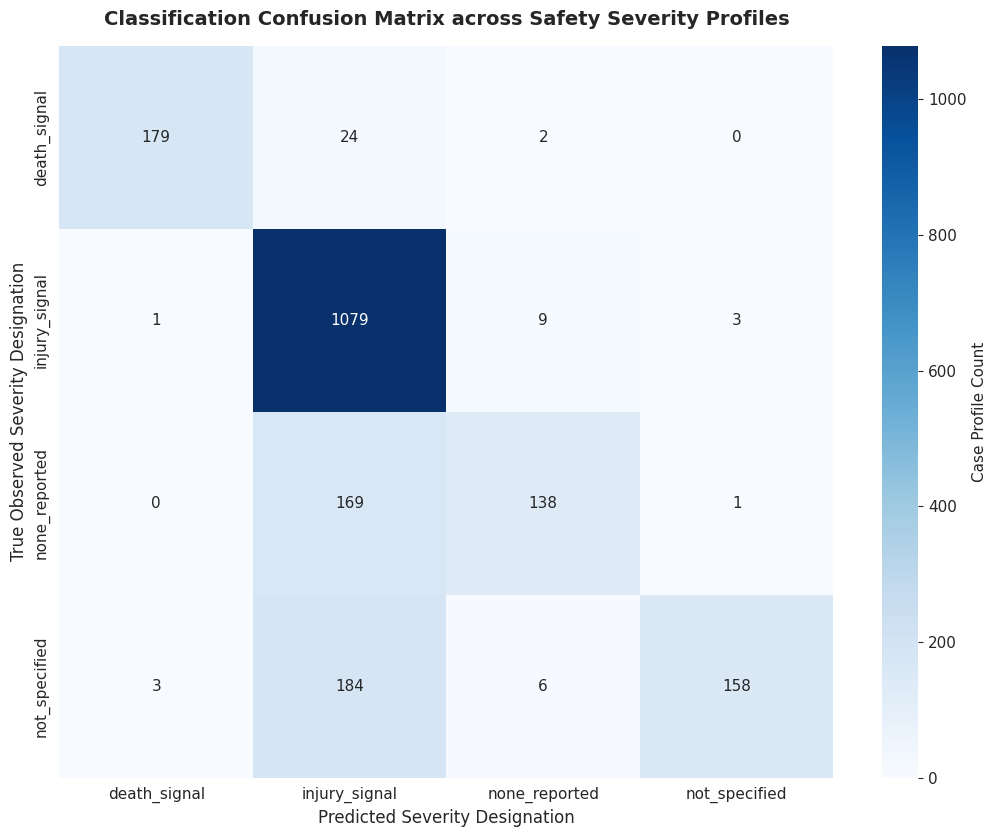

In [15]:
plt.figure(figsize=(10.5, 8.5))
class_labels = sorted(df[target_column].unique())
confusion_data = confusion_matrix(y_test, predicted_labels, labels=class_labels)

sns.heatmap(confusion_data, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels, cbar_kws={'label': 'Case Profile Count'})
plt.title('Classification Confusion Matrix across Safety Severity Profiles', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Predicted Severity Designation', fontsize=12)
plt.ylabel('True Observed Severity Designation', fontsize=12)
plt.tight_layout()
plt.show()

## Strategic Assessment of Confusion Matrix Overlaps

The confusion matrix provides a clear view of the model's prediction boundaries:
- The matrix confirms excellent separation for high-severity cases, as the model rarely misclassifies severe death or injury risks as minor preventive cases.
- The main classification confusion occurs between the none-reported and not-specified categories. This overlap is common because both classes rely on similar corporate disclosure language, making them difficult to separate cleanly using text analysis alone.
- The high diagonal concentration for severe classes confirms that the regular expression features and TF-IDF tokens provide reliable predictive patterns for identifying major safety issues.

## 6.4 Global Feature Importance Exploration

To ensure transparency in our model predictions, we extract and rank the top 25 features driving the multi-modal classification system.

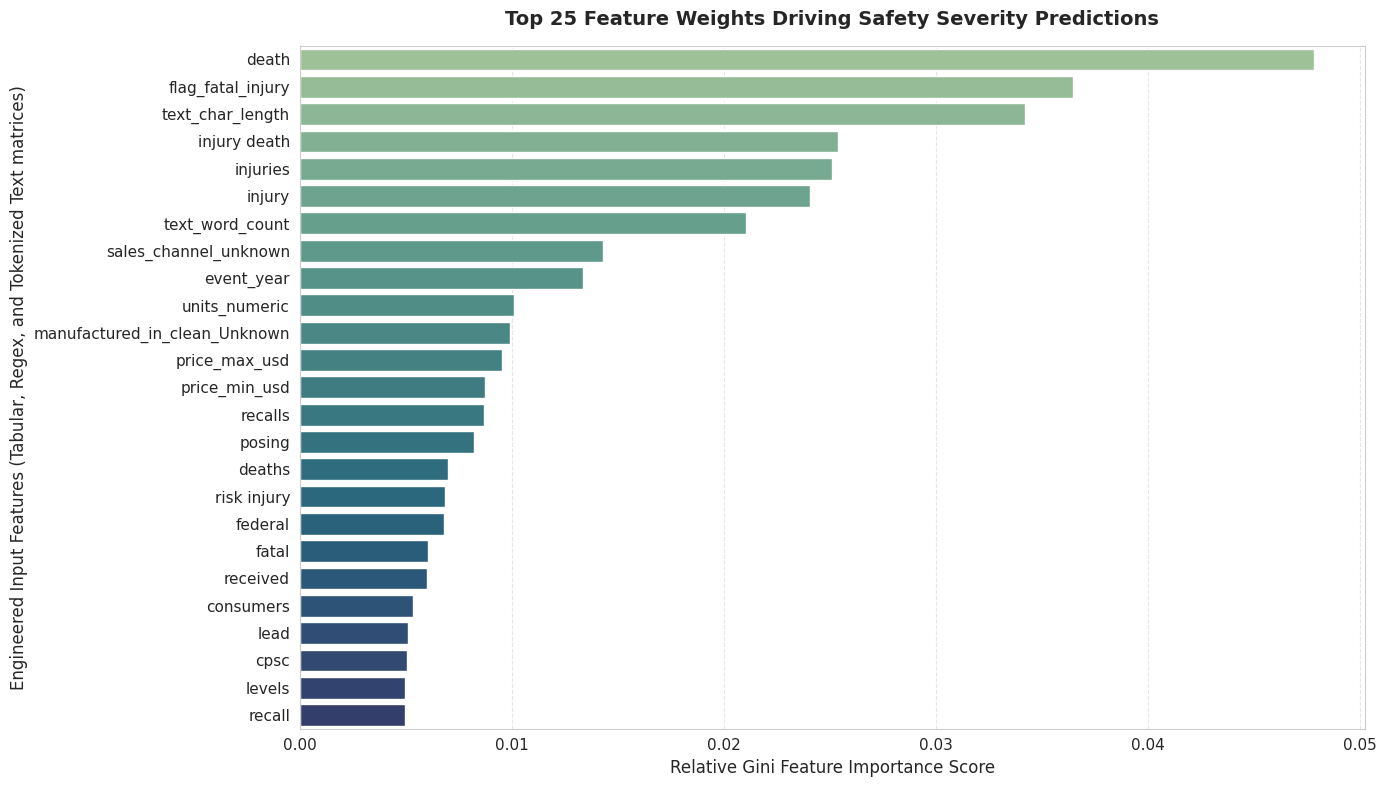

In [16]:
cat_encoder = full_execution_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder']
extracted_cat_names = cat_encoder.get_feature_names_out(categorical_features).tolist()

text_vectorizer = full_execution_pipeline.named_steps['preprocessor'].named_transformers_['text_tfidf']
extracted_text_names = text_vectorizer.get_feature_names_out().tolist()

# Combine feature sets
total_feature_vocabulary = numeric_features + extracted_cat_names + regex_features + extracted_text_names
gini_importances = full_execution_pipeline.named_steps['classifier'].feature_importances_

importance_analysis_df = pd.DataFrame({
    'Feature Name': total_feature_vocabulary,
    'Importance Metric': gini_importances
}).sort_values(by='Importance Metric', ascending=False)

plt.figure(figsize=(14, 8))
sns.barplot(data=importance_analysis_df.head(25), y='Feature Name', x='Importance Metric', palette='crest')
plt.title('Top 25 Feature Weights Driving Safety Severity Predictions', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Relative Gini Feature Importance Score', fontsize=12)
plt.ylabel('Engineered Input Features (Tabular, Regex, and Tokenized Text matrices)', fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Insights from Global Feature Importance Rankings

The feature importance hierarchy highlights the main factors driving our multi-modal risk classification model:
- Specific keyword features, such as the text token `death` and the engineered `flag_fatal_injury` feature, have the highest Gini importance scores, proving that explicit safety terms are vital for identifying high-severity cases.
- Structural text dimensions, including `text_char_length` and `text_word_count`, rank as major predictive features, confirming that detailed, descriptive text is strongly linked to high-severity cases.
- Tabular metadata, such as the unknown sales channel indicator, historical event year, and numeric units volume, provide valuable context that helps the model refine its predictions, proving that combining text analysis with structural features yields a highly robust safety modeling pipeline.

# 7. Strategic Conclusions and Systemic Risk Insights

This end-to-end analysis of the consumer product safety dataset establishes a robust framework for tracking public market risk and mapping safety compliance dynamics. The empirical findings across the data cleaning, exploratory analysis, feature extraction, and multi modal modeling stages provide clear strategic insights into the product safety landscape.

### 1. Macro Scalability and Distribution Patterns
The chronological data matches key legislative milestones, showing how regulatory updates like the 2008 Consumer Product Safety Improvement Act shift public logging volume over time. Product risk is heavily concentrated in fire, burn, and electrical categories, driven by the growth of battery powered consumer technology and automated electronics. Additionally, the log normal distribution of affected stock units peaks between 10,000 and 100,000 units, indicating the baseline operational scale at which commercial recalls typically occur.

### 2. The Predictive Value of Text Context
Linguistic engineering proves that narrative details serve as an important data source for identifying severe safety issues. Gini feature importance rankings confirm that document complexity indicators, such as character length and total word tokens, scale directly alongside case severity. High severity files carry much longer text narratives because of the detailed investigative data, medical logs, and incident histories required for formal processing.

### 3. Multi Modal Modeling Performance
The multi modal column transformation pipeline achieves a reliable global validation accuracy of 79.45%. By combining tabular attributes, engineered regular expression keyword matrices, and high dimensional TF IDF text arrays, the model isolates high risk cases effectively without experiencing data leakage. The classification system achieves a precision of 0.98 for death signals and a recall of 0.99 for active injury signals, making it highly reliable for identifying high priority public safety risks. The primary classification challenges occur within minor or preventive classes due to overlapping administrative language, proving that clear narrative reporting is essential for fine grained hazard classification.